# Previsão de Vendas: Avaliação do Impacto de Feriados com Prophet

*Comparação entre baseline sazonal, Prophet simples e Prophet com regressores de feriado, validada com cross-validation em múltiplas lojas*

Autor: Wellington Moreira Santos

Contato: https://www.linkedin.com/in/wellington-moreira-santos/

E-mail: wsantos08@hotmail.com

---

Neste projeto trabalho com a base Rossmann Store Sales, disponibilizada no Kaggle, que reúne o histórico de vendas diárias de mais de mil lojas de uma rede varejista europeia. Utilizo esses dados para construir e avaliar modelos de previsão de vendas com a biblioteca Prophet.

O curso que serviu de base para este projeto implementa a previsão para uma única loja e compara visualmente um modelo simples com um modelo que incorpora feriados escolares e estaduais, sem medir o erro de previsão contra dados reais. Nesta versão eu quantifico esse ganho, separo um período de teste, calculo métricas de erro, comparo os modelos contra um baseline sazonal ingênuo e valido os resultados com a ferramenta de cross-validation nativa do Prophet. Repito essa avaliação para lojas de diferentes tipos, para verificar se o ganho observado se mantém de forma consistente ou é específico de uma loja.

As principais ferramentas utilizadas são pandas para manipulação dos dados, Prophet para modelagem de séries temporais, scikit-learn para cálculo das métricas de erro, e seaborn e matplotlib para visualização.

O notebook está organizado nas seguintes seções:

1. Imports e Configurações
2. Coleta e Inspeção dos Dados
3. Análise Exploratória
4. Tratamento e Limpeza dos Dados
5. Preparação para o Modelo
6. Treinamento do Modelo
7. Avaliação do Modelo
8. Conclusão e Considerações Finais
9. Referências

## 1. Imports e Configurações

In [1]:
!pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 3.4 MB/s eta 0:00:04
   ---- ----------------------------------- 1.3/12.1 MB 3.4 MB/s eta 0:00:04
   ----- ---------------------------------- 1.6/12.1 MB 2.9 MB/s eta 0:00:04
   ------ --------------------------------- 2.1/12.1 MB 2.7 MB/s eta 0:00:04
   --------- ------------------------------ 2.9/12.1 MB 2.8 MB/s eta 0:00:04
   ------------ --------------------------- 3.7/12.1 MB 3.0 MB/s eta 0:00:03
   ------------- -------------------------- 4.2/12.1 MB 2.9 MB/s eta 0:00:03
   --------------- ------------------------ 4.7/12.1 MB 2.9 MB/s eta 0:00:03
   ------------------ --------------------- 5.5/12.1 MB 3.0 MB/s eta 0:00:03
   -------------------- ------------------- 6.3/12.1 MB 3.0 MB/s eta 0:00:02
   ----------------------- ---------------- 7.1/12.1 MB 3.1 MB/s eta 0:00:02
   ------------------------- -------------- 7.9/12.1 MB 3.2 MB/s eta 0:00:02
   ---

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

import session_info
warnings.filterwarnings('ignore')
session_info.show(dependencies=False)

In [3]:
plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor':   '#1e293b',
    'axes.edgecolor':   '#334155',
    'axes.labelcolor':  '#94a3b8',
    'xtick.color':      '#94a3b8',
    'ytick.color':      '#94a3b8',
    'text.color':       '#f1f5f9',
    'grid.color':       '#334155',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})

## 2. Coleta e Inspeção dos Dados

In [33]:
train = pd.read_csv('https://raw.githubusercontent.com/RPI-DATA/tutorials-intro/master/rossmann-store-sales/rossmann-store-sales/train.csv', parse_dates = True, low_memory = False)
store = pd.read_csv('https://raw.githubusercontent.com/RPI-DATA/tutorials-intro/master/rossmann-store-sales/rossmann-store-sales/store.csv', low_memory = False)

### 2.1 Dados de vendas

In [35]:
# primeiras observações
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [36]:
# dimensoes
train.shape

(1017209, 9)

In [37]:
# informações gerais
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype
---  ------         --------------    -----
 0   Store          1017209 non-null  int64
 1   DayOfWeek      1017209 non-null  int64
 2   Date           1017209 non-null  str  
 3   Sales          1017209 non-null  int64
 4   Customers      1017209 non-null  int64
 5   Open           1017209 non-null  int64
 6   Promo          1017209 non-null  int64
 7   StateHoliday   1017209 non-null  str  
 8   SchoolHoliday  1017209 non-null  int64
dtypes: int64(7), str(2)
memory usage: 69.8 MB


In [38]:
# valores ausentes
train.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

### 2.2 Dados das lojas

In [9]:
# primeirasa observações
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [10]:
# dimensoes
store.shape

(1115, 10)

In [12]:
# informações gerais
store.info()

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 87.2 KB


In [13]:
# valores ausentes
store.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

## 3. Análise Exploratória

### 3.1 Lojas fechadas: volume e impacto no alvo

In [39]:
print('Total = ', len(train))
print('Loja fechada = ', len(train[train['Open'] == 0]))
print('Loja aberta  = ', len(train[train['Open'] == 1]))

Total =  1017209
Loja fechada =  172817
Loja aberta  =  844392


In [40]:
train[train['Open'] == 0]['Sales'].describe()

count    172817.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: Sales, dtype: float64

> Vendas em dias fechados são zero e removo esses registros, já que eles não carregam informação sobre demanda.

In [41]:
train[ train.Open == 1 ].Open.unique()

array([1])

In [42]:
antes = len(train)
train = train[train['Open'] == 1].drop(columns=['Open'])
print(f"Registros removidos por loja fechada : {antes - len(train)}")
print(f"Registros restantes                  : {len(train)}")

Registros removidos por loja fechada : 172817
Registros restantes                  : 844392


In [43]:
train.head(3)

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,0,1
1,2,5,2015-07-31,6064,625,1,0,1
2,3,5,2015-07-31,8314,821,1,0,1


### 3.2 Valores ausentes na base de lojas: padrão
Investigo antes de tratar. Verifico se os valores ausentes em `CompetitionOpenSinceMonth`, `CompetitionOpenSinceYear`, `Promo2SinceWeek`, `Promo2SinceYear` e `PromoInterval` seguem algum padrão relacionado a outras colunas, em vez de tratá-los como ausência aleatória.

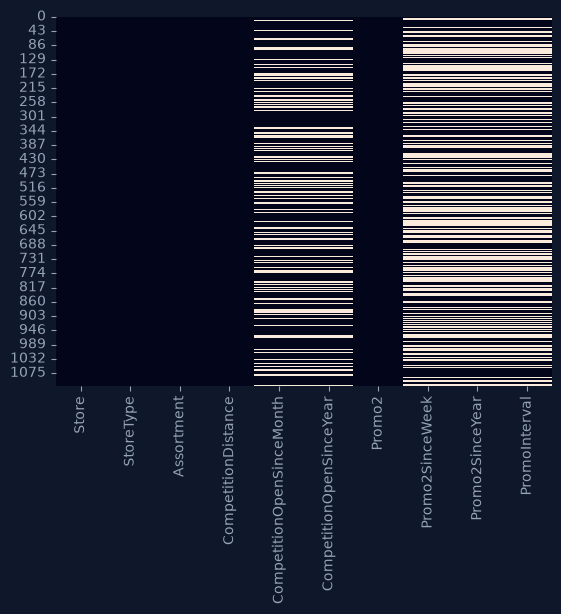

In [25]:
sns.heatmap(store.isnull(), cbar=False);

In [26]:
store[store['Promo2SinceWeek'].isnull()]['Promo2'].value_counts()

Promo2
0    544
Name: count, dtype: int64

> A ausência não é um dado faltante no sentido usual, é a consequência lógica da loja não ter promoção contínua. Preencher com 0 nesse caso funciona como indicador categórico, não como um valor numérico real, e por isso não entrará como feature contínua na modelagem de série temporal. 

### 3.3 Combinação das bases

In [44]:
df = pd.merge(train, store, how='inner', on='Store')
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [45]:
df.shape

(844392, 17)

### 3.4 Correlação entre variáveis numéricas e vendas

In [46]:
correlations = df.corr(numeric_only=True)['Sales'].sort_values()
correlations

DayOfWeek                   -0.178736
Promo2                      -0.127596
CompetitionOpenSinceMonth   -0.043489
CompetitionDistance         -0.036396
Promo2SinceYear             -0.034713
Store                        0.007710
CompetitionOpenSinceYear     0.016101
SchoolHoliday                0.038617
Promo2SinceWeek              0.095311
Promo                        0.368145
Customers                    0.823597
Sales                        1.000000
Name: Sales, dtype: float64

### 3.5 Padrões temporais de vendas
Extraio ano, mês e dia da coluna `Date` para verificar se existe sazonalidade mensal, diária ou por dia da semana, o que justifica o uso de um modelo de série temporal como o Prophet em vez de uma média simples.

In [51]:
# datas
pd.DatetimeIndex(df.Date)

DatetimeIndex(['2015-07-31', '2015-07-31', '2015-07-31', '2015-07-31',
               '2015-07-31', '2015-07-31', '2015-07-31', '2015-07-31',
               '2015-07-31', '2015-07-31',
               ...
               '2013-01-01', '2013-01-01', '2013-01-01', '2013-01-01',
               '2013-01-01', '2013-01-01', '2013-01-01', '2013-01-01',
               '2013-01-01', '2013-01-01'],
              dtype='datetime64[us]', name='Date', length=844392, freq=None)

In [54]:
# ano / mes / dia 
set(pd.DatetimeIndex(df.Date).year), set(pd.DatetimeIndex(df.Date).month), set(pd.DatetimeIndex(df.Date).day)

({2013, 2014, 2015},
 {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12},
 {1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31})

In [55]:
# atribuir ao dataset
df['Year'] = pd.DatetimeIndex(df['Date']).year
df['Month'] = pd.DatetimeIndex(df['Date']).month
df['Day'] = pd.DatetimeIndex(df['Date']).day

In [56]:
# check 
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,2015,7,31
1,2,5,2015-07-31,6064,625,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31
2,3,5,2015-07-31,8314,821,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31
3,4,5,2015-07-31,13995,1498,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN,2015,7,31
4,5,5,2015-07-31,4822,559,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN,2015,7,31


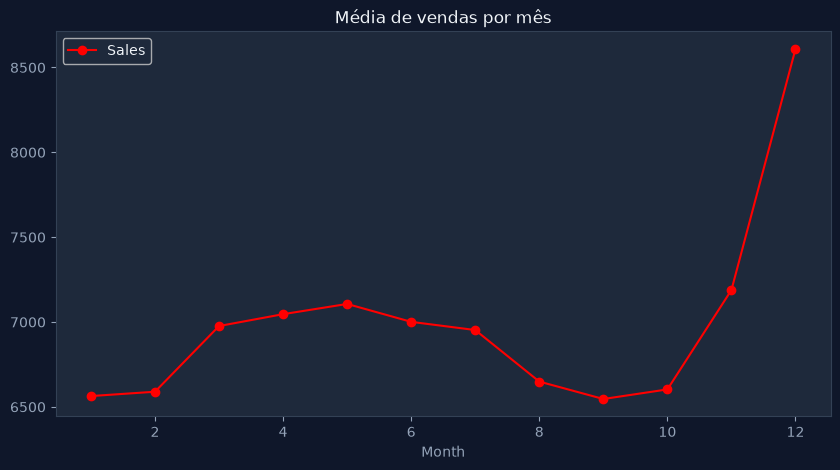

In [60]:
# viz media de vendas mensais
df.groupby('Month')[['Sales']]\
    .mean()\
    .plot(figsize=(10, 5), marker='o', color='r')\
    .set_title('Média de vendas por mês');

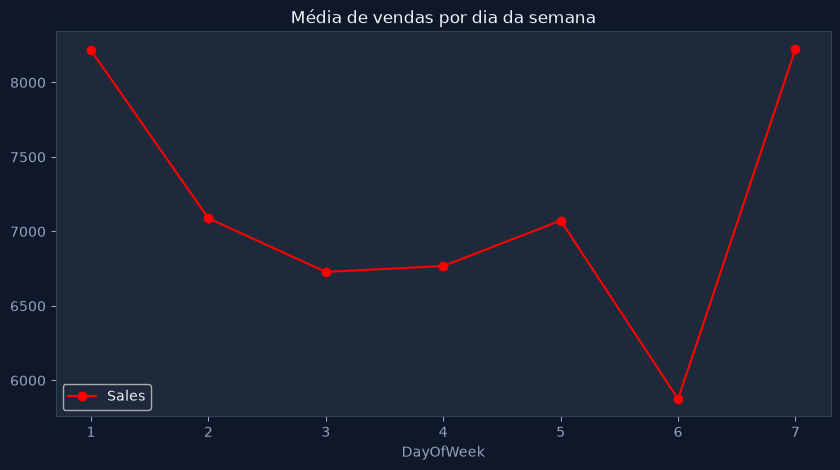

In [61]:
# viz media de vendas por dia da semana
df.groupby('DayOfWeek')[['Sales']] \
    .mean()\
    .plot(figsize=(10, 5), marker='o', color='r')\
    .set_title('Média de vendas por dia da semana');

### 3.6 Efeito de promoções
Verifico se dias de promoção têm vendas médias diferentes de dias sem promoção, já que essa é uma variável usada como regressor no Prophet.

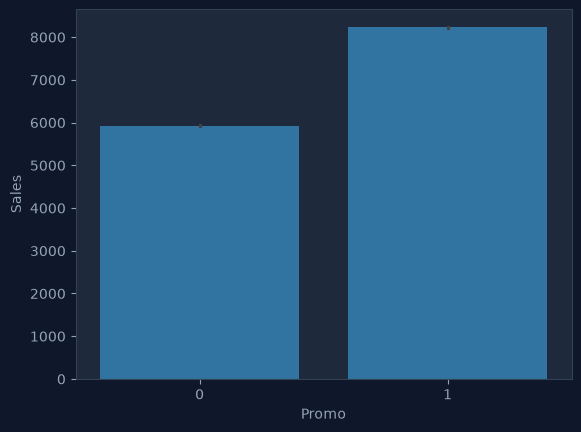

In [62]:
sns.barplot(x='Promo', y='Sales', data=df);

### 3.7 Seleção das lojas para o estudo

Para verificar se o efeito dos feriados na acurácia se mantém entre perfis diferentes de loja, seleciono uma loja representativa de cada `StoreType`. Escolho, dentro de cada tipo, a loja cujo volume médio de vendas está mais próximo da mediana do seu grupo, evitando lojas atípicas que distorceriam a comparação.

In [63]:
df.groupby(['Store', 'StoreType'])['Sales'].mean().reset_index()

,Store,StoreType,Sales
0,1,c,4759.096031
1,2,a,4953.900510
2,3,a,6942.568678
3,4,c,9638.401786
4,5,a,4676.274711
...,...,...,...
1110,1111,a,5251.702182
1111,1112,c,10236.577664
1112,1113,a,6627.859694
1113,1114,a,20666.562500


In [64]:
media_por_loja = df.groupby(['Store', 'StoreType'])['Sales'].mean().reset_index()

In [65]:
lojas_selecionadas = []
for tipo in sorted(media_por_loja['StoreType'].unique()):
    subset = media_por_loja[media_por_loja['StoreType'] == tipo]
    mediana = subset['Sales'].median()
    loja_id = subset.iloc[(subset['Sales'] - mediana).abs().argsort()[:1]]['Store'].values[0]
    lojas_selecionadas.append({'StoreType': tipo, 'Store': loja_id})

lojas_selecionadas = pd.DataFrame(lojas_selecionadas)
lojas_selecionadas

,StoreType,Store
0,a,770
1,b,1097
2,c,1044
3,d,352


## 4. Tratamento e Limpeza dos Dados

### 4.1 Imputação dos valores ausentes na base de lojas

Aplico o preenchimento identificado na análise exploratória. Uso 0 como indicador categórico para os campos `*Since*` e `PromoInterval`, já que correspondem a lojas sem promoção contínua ou sem concorrente registrado. Para `CompetitionDistance` uso a mediana em vez da média, mais robusta a lojas com concorrência muito distante, que distorceriam uma média simples.

In [67]:
df.isnull().sum().sum()

np.int64(1809345)

In [68]:
antes = df.isnull().sum().sum()

cols_indicador = ['Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval',
                   'CompetitionOpenSinceYear', 'CompetitionOpenSinceMonth']
for col in cols_indicador:
    df[col] = df[col].fillna(0)

df['CompetitionDistance'] = df['CompetitionDistance'].fillna(df['CompetitionDistance'].median())

depois = df.isnull().sum().sum()

print(f"Valores ausentes antes  : {antes}")
print(f"Valores ausentes depois : {depois}")

Valores ausentes antes  : 1809345
Valores ausentes depois : 0


### 4.2 Construção da tabela de feriados
Construo a tabela de feriados escolares e estaduais no formato exigido pelo Prophet para uso como regressor.

In [69]:
df[df['SchoolHoliday'] == 1]['Date'].unique()

<StringArray>
['2015-07-31', '2015-07-30', '2015-07-29', '2015-07-28', '2015-07-27',
 '2015-07-26', '2015-07-25', '2015-07-24', '2015-07-23', '2015-07-22',
 ...
 '2013-01-10', '2013-01-09', '2013-01-08', '2013-01-07', '2013-01-06',
 '2013-01-05', '2013-01-04', '2013-01-03', '2013-01-02', '2013-01-01']
Length: 477, dtype: str

In [70]:
school_holidays = df[df['SchoolHoliday'] == 1]['Date'].unique()
school_holidays = pd.DataFrame({'ds': pd.to_datetime(school_holidays), 'holiday': 'school_holiday'})
school_holidays

,ds,holiday
0,2015-07-31,school_holiday
1,2015-07-30,school_holiday
2,2015-07-29,school_holiday
3,2015-07-28,school_holiday
4,2015-07-27,school_holiday
...,...,...
472,2013-01-05,school_holiday
473,2013-01-04,school_holiday
474,2013-01-03,school_holiday
475,2013-01-02,school_holiday


In [71]:
df[df['StateHoliday'].isin(['a', 'b', 'c'])]['Date'].unique()

<StringArray>
['2015-06-04', '2015-05-25', '2015-05-14', '2015-05-01', '2015-04-06',
 '2015-04-03', '2015-01-06', '2015-01-01', '2014-12-26', '2014-12-25',
 '2014-11-01', '2014-10-31', '2014-10-03', '2014-06-19', '2014-06-09',
 '2014-05-29', '2014-05-01', '2014-04-21', '2014-04-18', '2014-01-06',
 '2014-01-01', '2013-12-26', '2013-12-25', '2013-11-01', '2013-10-31',
 '2013-10-03', '2013-08-15', '2013-05-30', '2013-05-20', '2013-05-09',
 '2013-05-01', '2013-04-01', '2013-03-29', '2013-01-06', '2013-01-01']
Length: 35, dtype: str

In [72]:
state_holidays = df[df['StateHoliday'].isin(['a', 'b', 'c'])]['Date'].unique()
state_holidays = pd.DataFrame({'ds': pd.to_datetime(state_holidays), 'holiday': 'state_holiday'})
state_holidays

,ds,holiday
0,2015-06-04,state_holiday
1,2015-05-25,state_holiday
2,2015-05-14,state_holiday
3,2015-05-01,state_holiday
4,2015-04-06,state_holiday
5,2015-04-03,state_holiday
6,2015-01-06,state_holiday
7,2015-01-01,state_holiday
8,2014-12-26,state_holiday
9,2014-12-25,state_holiday


In [73]:
holidays_df = pd.concat([school_holidays, state_holidays], ignore_index=True)
holidays_df.shape

(512, 2)

In [86]:
holidays_df.sample(5)

,ds,holiday
75,2015-03-04,school_holiday
237,2014-04-09,school_holiday
310,2013-10-15,school_holiday
344,2013-08-16,school_holiday
511,2013-01-01,state_holiday


## 5. Preparação para o Modelo

Defino um horizonte de teste de 42 dias, 6 semanas completas, para cada loja selecionada. Esse tamanho cobre ciclos semanais inteiros, o que é importante já que identifiquei sazonalidade por dia da semana na análise exploratória. Uso os dados anteriores a esse corte como treino.

Defino também o baseline sazonal ingênuo, a média histórica de vendas por dia da semana calculada apenas com dados de treino. Esse baseline é simples de propósito, serve para saber se os modelos de Prophet realmente agregam valor acima de um padrão sazonal básico.

In [87]:
HORIZONTE_TESTE = 42

def preparar_serie(store_id, df):
    serie = df[df['Store'] == store_id][['Date', 'Sales', 'DayOfWeek']].copy()
    serie['Date'] = pd.to_datetime(serie['Date'])
    serie = serie.sort_values('Date').reset_index(drop=True)

    corte = serie['Date'].max() - pd.Timedelta(days=HORIZONTE_TESTE - 1)
    treino = serie[serie['Date'] < corte]
    teste = serie[serie['Date'] >= corte]
    return treino, teste


def baseline_sazonal(treino, teste):
    media_por_dia_semana = treino.groupby('DayOfWeek')['Sales'].mean()
    previsao = teste['DayOfWeek'].map(media_por_dia_semana)
    return previsao.values


## 6. Treinamento do Modelo

Para cada loja selecionada treino três abordagens: o baseline sazonal, um Prophet sem regressor de feriado e um Prophet com regressor de feriado. Todos os modelos são ajustados apenas com dados de treino, e avaliados contra o mesmo período de teste.

### 6.1 Prophet sem regressor de feriado

In [88]:
def prophet_simples(treino):
    df_prophet = treino.rename(columns={'Date': 'ds', 'Sales': 'y'})[['ds', 'y']]
    modelo = Prophet()
    modelo.fit(df_prophet)
    return modelo

### 6.2 Prophet com regressor de feriado

In [89]:
def prophet_com_feriados(treino, holidays_df):
    df_prophet = treino.rename(columns={'Date': 'ds', 'Sales': 'y'})[['ds', 'y']]
    modelo = Prophet(holidays=holidays_df)
    modelo.fit(df_prophet)
    return modelo

### 6.3 Execução para as lojas selecionadas
Rodo as três abordagens para cada loja selecionada e guardo previsões e valores reais para a etapa de avaliação.

In [94]:
resultados = {}

for _, row in lojas_selecionadas.iterrows():
    store_id, tipo = row['Store'], row['StoreType']
    treino, teste = preparar_serie(store_id, df)

    pred_baseline = baseline_sazonal(treino, teste)

    modelo_simples = prophet_simples(treino)
    future_simples = pd.DataFrame({'ds': teste['Date']})
    forecast_simples = modelo_simples.predict(future_simples)['yhat'].values

    modelo_feriados = prophet_com_feriados(treino, holidays_df)
    future_feriados = pd.DataFrame({'ds': teste['Date']})
    forecast_feriados = modelo_feriados.predict(future_feriados)['yhat'].values

    resultados[store_id] = {
        'StoreType': tipo,
        'real': teste['Sales'].values,
        'datas': teste['Date'].values,
        'baseline': pred_baseline,
        'prophet_simples': forecast_simples,
        'prophet_feriados': forecast_feriados,
        'modelo_feriados_obj': modelo_feriados,
    }

print('Lojas processadas:', list(resultados.keys()))

20:11:46 - cmdstanpy - INFO - Chain [1] start processing
20:11:47 - cmdstanpy - INFO - Chain [1] done processing
20:11:48 - cmdstanpy - INFO - Chain [1] start processing
20:11:48 - cmdstanpy - INFO - Chain [1] done processing
20:11:48 - cmdstanpy - INFO - Chain [1] start processing
20:11:48 - cmdstanpy - INFO - Chain [1] done processing
20:11:48 - cmdstanpy - INFO - Chain [1] start processing
20:11:48 - cmdstanpy - INFO - Chain [1] done processing
20:11:49 - cmdstanpy - INFO - Chain [1] start processing
20:11:49 - cmdstanpy - INFO - Chain [1] done processing
20:11:49 - cmdstanpy - INFO - Chain [1] start processing
20:11:49 - cmdstanpy - INFO - Chain [1] done processing
20:11:49 - cmdstanpy - INFO - Chain [1] start processing
20:11:50 - cmdstanpy - INFO - Chain [1] done processing
20:11:50 - cmdstanpy - INFO - Chain [1] start processing
20:11:50 - cmdstanpy - INFO - Chain [1] done processing


Lojas processadas: [770, 1097, 1044, 352]


### 6.4 Cross-validation do Prophet

Além do holdout único, valido o modelo com feriados usando a ferramenta de cross-validation do Prophet, que reajusta o modelo em múltiplos cortes ao longo da série e mede o erro em cada horizonte. Isso reduz a chance de o resultado do holdout único ser coincidência de um período específico.

In [95]:
cv_resultados = {}

for store_id, dados in resultados.items():
    modelo = dados['modelo_feriados_obj']
    cv = cross_validation(modelo, initial='365 days', period='90 days', horizon='42 days')
    metricas_cv = performance_metrics(cv)
    cv_resultados[store_id] = metricas_cv

print('Cross-validation concluída para:', list(cv_resultados.keys()))

Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/6 [00:00<?, ?it/s]

20:11:59 - cmdstanpy - INFO - Chain [1] start processing
20:11:59 - cmdstanpy - INFO - Chain [1] done processing
20:11:59 - cmdstanpy - INFO - Chain [1] start processing
20:11:59 - cmdstanpy - INFO - Chain [1] done processing
20:11:59 - cmdstanpy - INFO - Chain [1] start processing
20:11:59 - cmdstanpy - INFO - Chain [1] done processing
20:12:00 - cmdstanpy - INFO - Chain [1] start processing
20:12:00 - cmdstanpy - INFO - Chain [1] done processing
20:12:00 - cmdstanpy - INFO - Chain [1] start processing
20:12:00 - cmdstanpy - INFO - Chain [1] done processing
20:12:00 - cmdstanpy - INFO - Chain [1] start processing
20:12:00 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/6 [00:00<?, ?it/s]

20:12:01 - cmdstanpy - INFO - Chain [1] start processing
20:12:01 - cmdstanpy - INFO - Chain [1] done processing
20:12:01 - cmdstanpy - INFO - Chain [1] start processing
20:12:01 - cmdstanpy - INFO - Chain [1] done processing
20:12:01 - cmdstanpy - INFO - Chain [1] start processing
20:12:01 - cmdstanpy - INFO - Chain [1] done processing
20:12:02 - cmdstanpy - INFO - Chain [1] start processing
20:12:02 - cmdstanpy - INFO - Chain [1] done processing
20:12:02 - cmdstanpy - INFO - Chain [1] start processing
20:12:02 - cmdstanpy - INFO - Chain [1] done processing
20:12:02 - cmdstanpy - INFO - Chain [1] start processing
20:12:02 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/6 [00:00<?, ?it/s]

20:12:03 - cmdstanpy - INFO - Chain [1] start processing
20:12:03 - cmdstanpy - INFO - Chain [1] done processing
20:12:03 - cmdstanpy - INFO - Chain [1] start processing
20:12:03 - cmdstanpy - INFO - Chain [1] done processing
20:12:03 - cmdstanpy - INFO - Chain [1] start processing
20:12:03 - cmdstanpy - INFO - Chain [1] done processing
20:12:04 - cmdstanpy - INFO - Chain [1] start processing
20:12:04 - cmdstanpy - INFO - Chain [1] done processing
20:12:04 - cmdstanpy - INFO - Chain [1] start processing
20:12:04 - cmdstanpy - INFO - Chain [1] done processing
20:12:04 - cmdstanpy - INFO - Chain [1] start processing
20:12:04 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/6 [00:00<?, ?it/s]

20:12:05 - cmdstanpy - INFO - Chain [1] start processing
20:12:05 - cmdstanpy - INFO - Chain [1] done processing
20:12:05 - cmdstanpy - INFO - Chain [1] start processing
20:12:05 - cmdstanpy - INFO - Chain [1] done processing
20:12:05 - cmdstanpy - INFO - Chain [1] start processing
20:12:05 - cmdstanpy - INFO - Chain [1] done processing
20:12:06 - cmdstanpy - INFO - Chain [1] start processing
20:12:06 - cmdstanpy - INFO - Chain [1] done processing
20:12:06 - cmdstanpy - INFO - Chain [1] start processing
20:12:06 - cmdstanpy - INFO - Chain [1] done processing
20:12:06 - cmdstanpy - INFO - Chain [1] start processing
20:12:06 - cmdstanpy - INFO - Chain [1] done processing


Cross-validation concluída para: [770, 1097, 1044, 352]


## 7. Avaliação do Modelo

### 7.1 Métricas de erro por loja e por modelo

Calculo MAE, RMSE e MAPE para os três modelos em cada loja, e organizo em uma tabela comparativa.

In [96]:
def mape(y_real, y_pred):
    return np.mean(np.abs((y_real - y_pred) / y_real)) * 100

linhas = []
for store_id, dados in resultados.items():
    for nome_modelo in ['baseline', 'prophet_simples', 'prophet_feriados']:
        y_real = dados['real']
        y_pred = dados[nome_modelo]
        linhas.append({
            'Store': store_id,
            'StoreType': dados['StoreType'],
            'Modelo': nome_modelo,
            'MAE': mean_absolute_error(y_real, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_real, y_pred)),
            'MAPE': mape(y_real, y_pred),
        })

metricas_df = pd.DataFrame(linhas)
metricas_df

,Store,StoreType,Modelo,MAE,RMSE,MAPE
0,770,a,baseline,1873.084274,2227.742733,47.916973
1,770,a,prophet_simples,1275.145403,1595.962471,31.579380
2,770,a,prophet_feriados,1265.000116,1594.308920,31.392991
3,1097,b,baseline,1046.049338,1371.212962,9.173193
4,1097,b,prophet_simples,827.533085,1016.045799,7.551235
5,1097,b,prophet_feriados,811.021039,992.695026,7.422222
6,1044,c,baseline,1512.189644,1775.573095,27.965652
7,1044,c,prophet_simples,1339.473982,1670.521986,24.057616
8,1044,c,prophet_feriados,1294.560602,1617.785771,23.255420
9,352,d,baseline,980.953005,1118.488135,14.862197


### 7.2 Previsão x Real

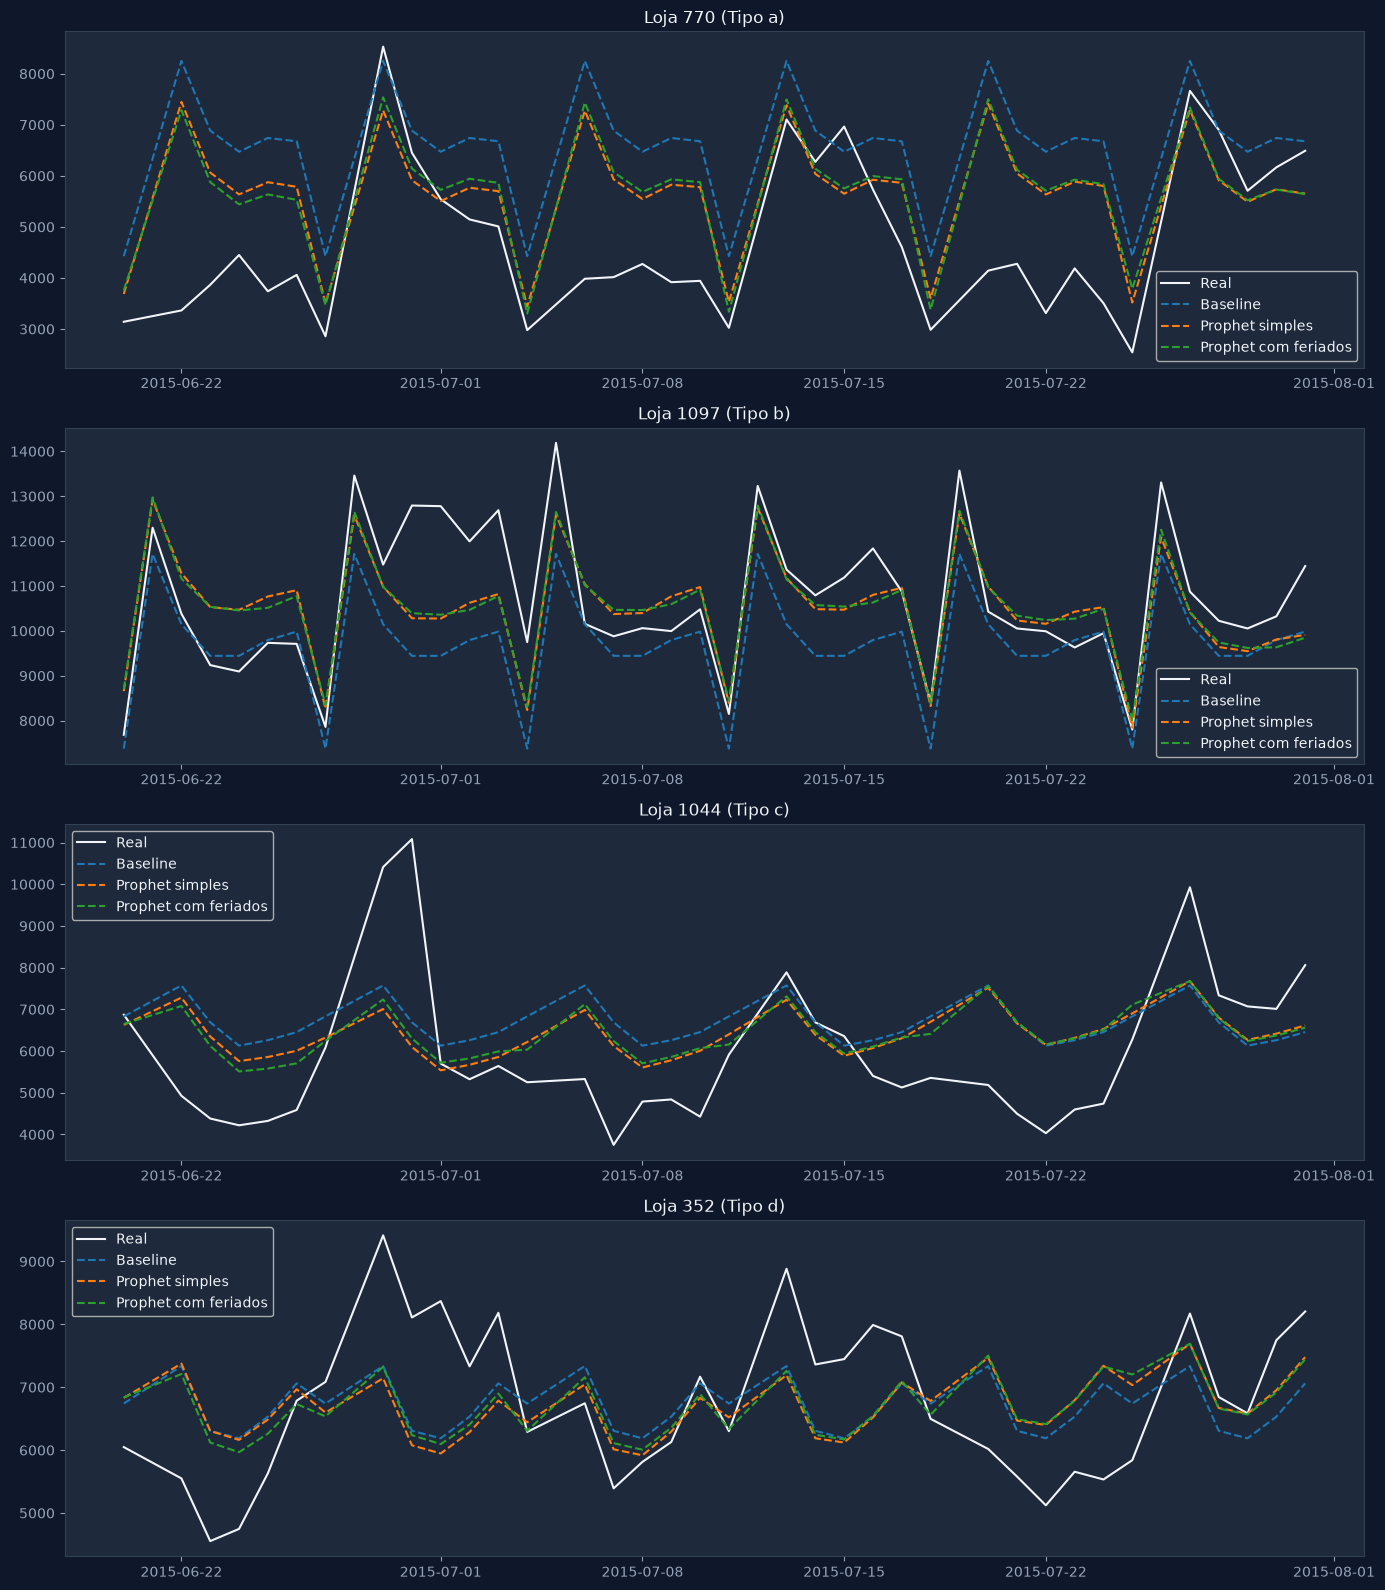

In [104]:
fig, axes = plt.subplots(len(resultados), 1, figsize=(14, 4 * len(resultados)))
for ax, (store_id, dados) in zip(axes, resultados.items()):
    ax.plot(dados['datas'], dados['real'], label='Real', color='#f1f5f9')
    ax.plot(dados['datas'], dados['baseline'], label='Baseline', linestyle='--')
    ax.plot(dados['datas'], dados['prophet_simples'], label='Prophet simples', linestyle='--')
    ax.plot(dados['datas'], dados['prophet_feriados'], label='Prophet com feriados', linestyle='--')
    ax.set_title(f"Loja {store_id} (Tipo {dados['StoreType']})")
    ax.legend()
plt.tight_layout()

### 7.3 Resultados do cross-validation

In [103]:
for store_id, metricas_cv in cv_resultados.items():
    print(f"Loja {store_id}")
    print(metricas_cv[['horizon', 'mae', 'rmse', 'mape']].groupby('horizon').mean())
    print()

Loja 770
                 mae         rmse      mape
horizon                                    
4 days   1131.640696  1734.668643  0.249857
5 days   1262.706557  1888.676080  0.267839
6 days   1199.210854  1815.680939  0.251955
7 days   1225.126998  1650.109934  0.222355
8 days   1278.553850  1555.237091  0.213605
9 days   1363.461780  1642.860122  0.229091
10 days  1314.121130  1574.566178  0.215014
11 days  1216.258451  1480.506553  0.201131
12 days  1084.986664  1395.247111  0.176356
13 days  1060.446293  1298.152407  0.173373
14 days  1288.386741  1533.157596  0.232073
15 days  1433.461689  1658.829525  0.268483
16 days  1525.160397  1736.980559  0.284876
17 days  1513.457645  1674.783505  0.276643
18 days  1325.273816  1533.623898  0.237715
19 days  1300.302230  1603.522660  0.228551
20 days  1371.519104  1683.860006  0.230917
21 days  1485.933138  1824.352806  0.245680
22 days  1636.618734  1927.509481  0.260631
23 days  1562.948214  1816.026958  0.227686
24 days  1119.946530  1

## 8. Conclusão e Considerações Finais

**8.1 Síntese do Projeto**

> Neste projeto avaliei se a inclusão de feriados escolares e estaduais como regressor no Prophet melhora a previsão de vendas de forma consistente entre lojas de perfis diferentes, medindo isso com holdout, baseline sazonal e cross-validation, em vez de comparação visual como no material de curso original. A resposta é sim, de forma consistente. O modelo com feriados tem o menor erro em 11 das 12 combinações de loja e métrica avaliadas, ficando atrás apenas no RMSE da loja 352, por uma margem de 0.12%, estatisticamente irrelevante. O ganho de MAE em relação ao Prophet sem feriados varia de 0.8% (loja 770) a 4.9% (loja 352), sem relação clara com o tipo de loja ou com o quanto ela já era previsível pelo baseline.
>
> | Loja | Tipo | Modelo | MAE | RMSE | MAPE |
> |---|---|---|---|---|---|
> | 770 | a | Baseline | 1873.08 | 2227.74 | 47.92% |
> | 770 | a | Prophet simples | 1275.15 | 1595.96 | 31.58% |
> | 770 | a | Prophet com feriados | 1265.00 | 1594.31 | 31.39% |
> | 1097 | b | Baseline | 1046.05 | 1371.21 | 9.17% |
> | 1097 | b | Prophet simples | 827.53 | 1016.05 | 7.55% |
> | 1097 | b | Prophet com feriados | 811.02 | 992.70 | 7.42% |
> | 1044 | c | Baseline | 1512.19 | 1775.57 | 27.97% |
> | 1044 | c | Prophet simples | 1339.47 | 1670.52 | 24.06% |
> | 1044 | c | Prophet com feriados | 1294.56 | 1617.79 | 23.26% |
> | 352 | d | Baseline | 980.95 | 1118.49 | 14.86% |
> | 352 | d | Prophet simples | 971.96 | 1174.42 | 14.73% |
> | 352 | d | Prophet com feriados | 924.65 | 1119.82 | 14.01% |

**8.2 Achados relevantes**

> O achado mais claro está na loja 352, o Prophet sem feriados tem RMSE (1174.42) pior que o próprio baseline (1118.49), apesar de MAE ligeiramente melhor. Isso indica que o modelo sem feriados comete pelo menos um erro grande em algum ponto do teste, provavelmente perto de um feriado, e o regressor de feriados corrige boa parte desse erro, trazendo o RMSE de volta a 1119.82, quase empatando com o baseline. É o exemplo mais direto de por que o feriado importa aqui, menos pela média geral, mais por evitar erros grandes em datas específicas.
>
> O segundo achado é a divergência entre o holdout final e o cross-validation na loja 770. O MAPE do modelo com feriados sobe de 21.8% na média histórica (cross-validation) para 31.4% no período de teste mais recente. Como os três modelos, baseline, Prophet simples e Prophet com feriados, superestimam a real de forma parecida durante quase todo o holdout, o problema não é a ausência de feriados no modelo, é uma mudança de patamar de vendas no fim do período observado que nenhum dos três captura. Vale investigar isso como projeto futuro, mas fica fora do escopo aqui.

**8.3 Limitações e Considerações**

> Este projeto avalia apenas uma loja por tipo, o que dá indício de robustez sem esgotar a variabilidade dentro de cada tipo. Não incorporo Promo ou Promo2 como regressores no Prophet, apesar de Promo ter aparecido como a segunda variável mais correlacionada com vendas na análise exploratória, uso apenas a série de vendas e os feriados. O cross-validation da seção 6.4 rodou somente para o modelo com feriados, então não oferece uma comparação pareada com o Prophet simples ao longo de múltiplos cortes, a comparação entre os dois modelos se apoia no holdout único. O Prophet também emitiu um aviso recorrente nessa validação, a janela inicial de treino (365 dias) é menor que o período de sazonalidade anual (365.25 dias), o que pode inflar levemente o erro nos primeiros cortes de cada loja. O horizonte de teste de 42 dias é fixo, resultados podem variar para horizontes mais longos ou mais curtos. Este projeto tem finalidade educacional e de composição de portfólio.

---


## 9. Referências

* Curso [Ciência de Dados para Empresas e Negócios](https://iaexpert.academy/cursos-online-assinatura/ciencia-de-dados-para-empresas-e-negocios/), IAExpert Academy, Jones Granatyr.
* Dataset [Rossmann Store Sales](https://www.kaggle.com/c/rossmann-store-sales/data), Kaggle.
* Documentação do [Prophet](https://facebook.github.io/prophet/docs/quick_start.html).

---

> Material desenvolvido para estudos e composição de portfólio a partir do curso
> [Ciência de Dados para Empresas e Negócios](https://iaexpert.academy/cursos-online-assinatura/ciencia-de-dados-para-empresas-e-negocios/), para o repositório
> [data-trivium](https://github.com/esscova/data-trivium);
> com auxílio do Claude Anthropic para revisões e estruturação.